# Segment Events Budget Matrix Visualization

Heatmap of the budget matrix W = t_in - t_out, showing the free-window width per (pair, segment).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

import sys
sys.path.insert(0, '..')


from ksb.simulation.ksb_simulation import KSBSimulation

## Run simulation

In [2]:
# Load default config and adjust for visualization
config_path = Path("../configs/system/default.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)


print(f"Config: batch={cfg['batch']}, n_buffer_seg={cfg['n_buffer_seg']}")
print(f"Solver: {cfg.get('solver', 'scurve')}")

sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42)

W = result.segment_events.W
print(f"W shape: {W.shape}")
print(f"W range: [{W.min():.4f}, {W.max():.4f}]")

Config: batch=100, n_buffer_seg=7
Solver: ruckig
W shape: (99, 7)
W range: [-0.0605, 0.3960]


## Heatmap: Budget Matrix W

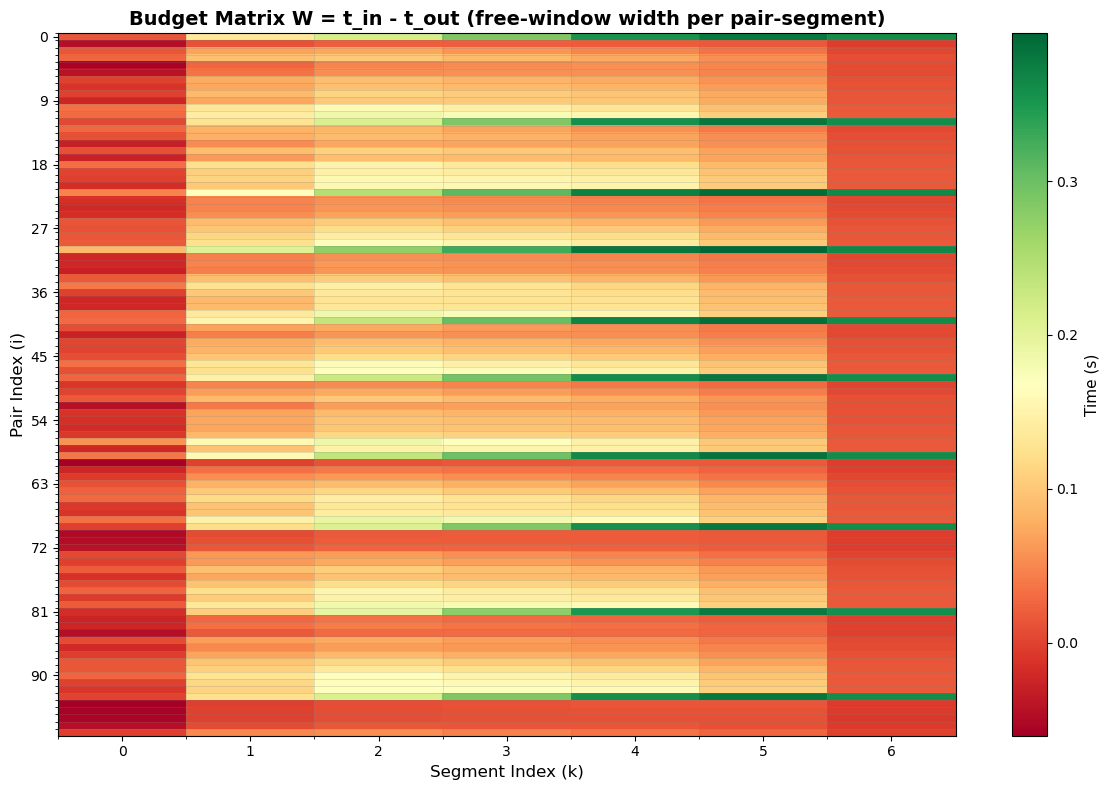

Heatmap saved to segment_events_W_heatmap.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
im = ax.imshow(W, cmap="RdYlGn", aspect="auto", interpolation="nearest")

# Labels and title
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Pair Index (i)", fontsize=12)
ax.set_title("Budget Matrix W = t_in - t_out (free-window width per pair-segment)", fontsize=14, fontweight="bold")

# Ticks
ax.set_xticks(np.arange(W.shape[1]))
ax.set_yticks(np.arange(0, W.shape[0], max(1, W.shape[0]//10)))  # Sparse y-ticks

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (s)", fontsize=11)

# Grid
ax.set_xticks(np.arange(W.shape[1]) - 0.5, minor=True)
ax.set_yticks(np.arange(W.shape[0]) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Heatmap saved to segment_events_W_heatmap.png")

## Summary Statistics

In [4]:
print("Budget Matrix W Statistics")
print("="*50)
print(f"Shape: {W.shape} (pairs × segments)")
print(f"Min value: {W.min():.6f} s")
print(f"Max value: {W.max():.6f} s")
print(f"Mean value: {W.mean():.6f} s")
print(f"Std dev: {W.std():.6f} s")
print()
print(f"Negative values (inverted windows): {np.sum(W < 0)} / {W.size}")
print(f"Positive values (normal windows): {np.sum(W > 0)} / {W.size}")
print()
print("Per-segment averages:")
for k in range(W.shape[1]):
    print(f"  Segment {k}: mean={W[:, k].mean():.6f} s, min={W[:, k].min():.6f} s, max={W[:, k].max():.6f} s")

Budget Matrix W Statistics
Shape: (99, 7) (pairs × segments)
Min value: -0.060496 s
Max value: 0.396017 s
Mean value: 0.079503 s
Std dev: 0.087401 s

Negative values (inverted windows): 69 / 693
Positive values (normal windows): 624 / 693

Per-segment averages:
  Segment 0: mean=-0.002883 s, min=-0.060496 s, max=0.088061 s
  Segment 1: mean=0.083199 s, min=-0.003352 s, max=0.205375 s
  Segment 2: mean=0.111151 s, min=0.008633 s, max=0.273632 s
  Segment 3: mean=0.112450 s, min=0.009659 s, max=0.328068 s
  Segment 4: mean=0.112674 s, min=0.010580 s, max=0.381453 s
  Segment 5: mean=0.095354 s, min=0.009610 s, max=0.396017 s
  Segment 6: mean=0.044575 s, min=-0.007398 s, max=0.364990 s


## Per-Pair Profile

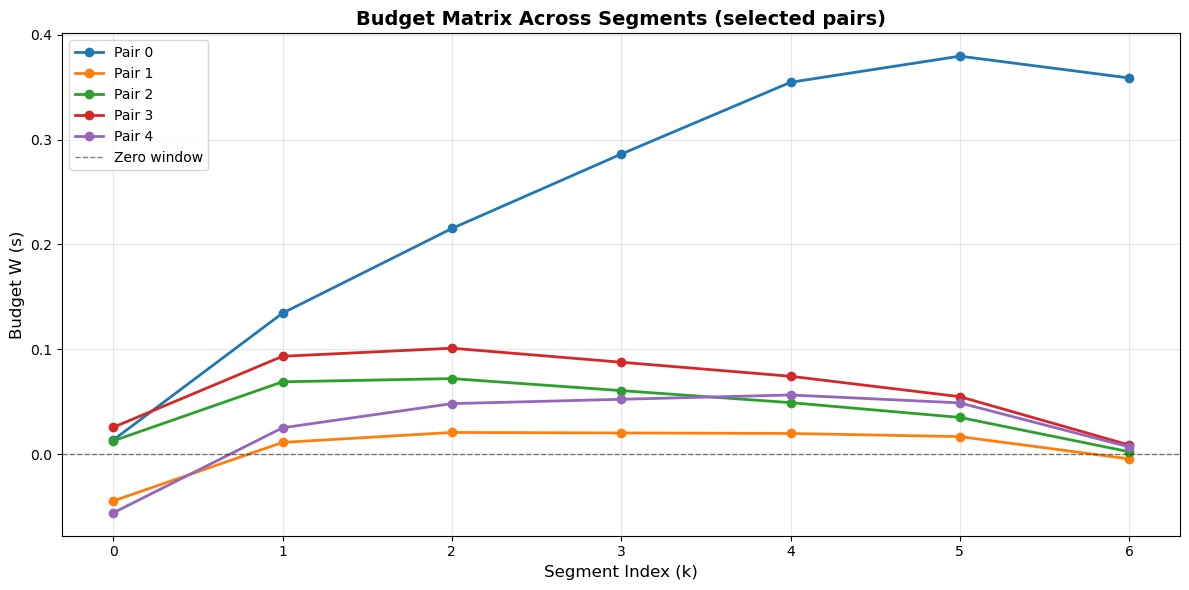

Profile plot saved to segment_events_W_profiles.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot W[i, :] for each pair as a line
for i in range(min(5, W.shape[0])):  # First 5 pairs
    ax.plot(W[i, :], marker="o", label=f"Pair {i}", linewidth=2, markersize=6)

ax.axhline(y=0, color="k", linestyle="--", linewidth=1, alpha=0.5, label="Zero window")
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Budget W (s)", fontsize=12)
ax.set_title("Budget Matrix Across Segments (selected pairs)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Profile plot saved to segment_events_W_profiles.png")

## Time Event Analysis

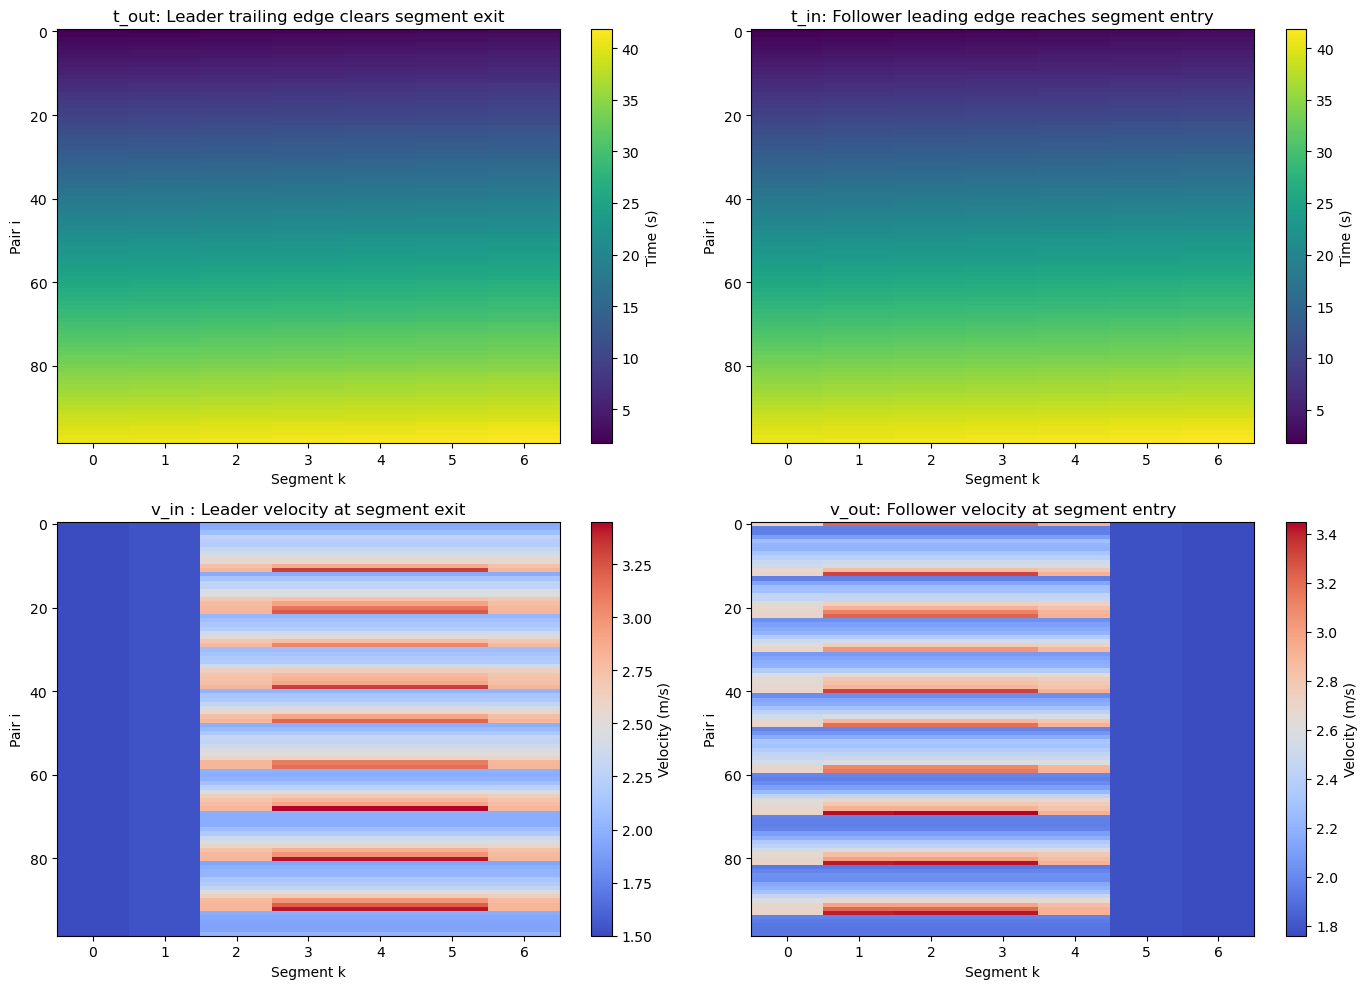

All event heatmaps saved to segment_events_all_heatmaps.png


In [6]:
t_out = result.segment_events.t_out
t_in = result.segment_events.t_in
v_in = result.segment_events.v_in
v_out = result.segment_events.v_out

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# t_out heatmap
im1 = axes[0, 0].imshow(t_out, cmap="viridis", aspect="auto")
axes[0, 0].set_title("t_out: Leader trailing edge clears segment exit")
axes[0, 0].set_xlabel("Segment k")
axes[0, 0].set_ylabel("Pair i")
plt.colorbar(im1, ax=axes[0, 0], label="Time (s)")

# t_in heatmap
im2 = axes[0, 1].imshow(t_in, cmap="viridis", aspect="auto")
axes[0, 1].set_title("t_in: Follower leading edge reaches segment entry")
axes[0, 1].set_xlabel("Segment k")
axes[0, 1].set_ylabel("Pair i")
plt.colorbar(im2, ax=axes[0, 1], label="Time (s)")

# v_in heatmap
im3 = axes[1, 0].imshow(v_in , cmap="coolwarm", aspect="auto")
axes[1, 0].set_title("v_in : Leader velocity at segment exit")
axes[1, 0].set_xlabel("Segment k")
axes[1, 0].set_ylabel("Pair i")
plt.colorbar(im3, ax=axes[1, 0], label="Velocity (m/s)")

# v_out heatmap
im4 = axes[1, 1].imshow(v_out, cmap="coolwarm", aspect="auto")
axes[1, 1].set_title("v_out: Follower velocity at segment entry")
axes[1, 1].set_xlabel("Segment k")
axes[1, 1].set_ylabel("Pair i")
plt.colorbar(im4, ax=axes[1, 1], label="Velocity (m/s)")

plt.tight_layout()
plt.show()

print("All event heatmaps saved to segment_events_all_heatmaps.png")

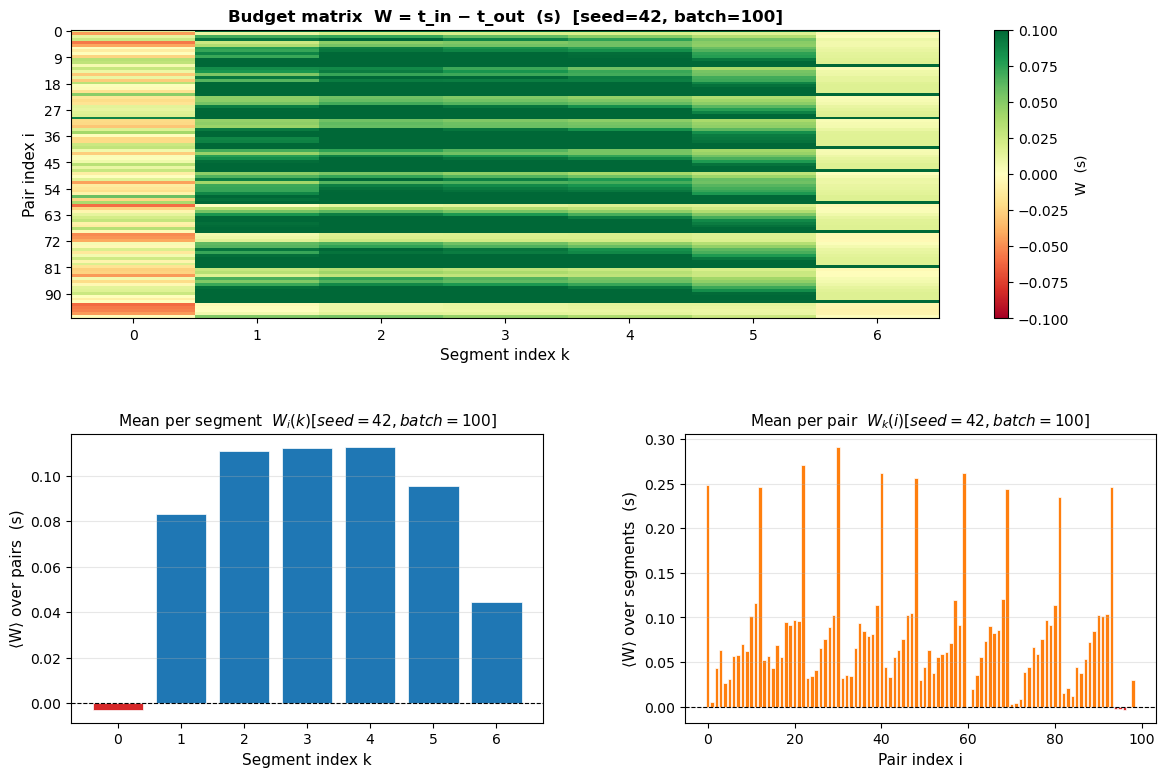

In [7]:
from ksb.visualization.segment_event_plots import plot_W_budget, plot_kinematic_margin

fig = plot_W_budget(result.segment_events, title_suffix=f"seed=42, batch={cfg['batch']}")

## Budget histograms: mean W per segment k and per pair i

`plot_W_budget` shows the full heatmap plus the two marginal means:
- **⟨W⟩_i(k)** — mean budget over all pairs for each segment index k (blue bars; red = negative mean)
- **⟨W⟩_k(i)** — mean budget over all segments for each pair index i (orange bars; red = negative mean)

## Kinematic Margin

`kinematic_margin[i, k] = W[i, k] - T_min[i, k]`, where `T_min` is the Ruckig minimum-time duration to synchronize the leader's exit state `(v⁻, a⁻)` to the follower's entry state `(v⁺, a⁺)`. Positive = feasible; negative = window too tight for kinematic correction.

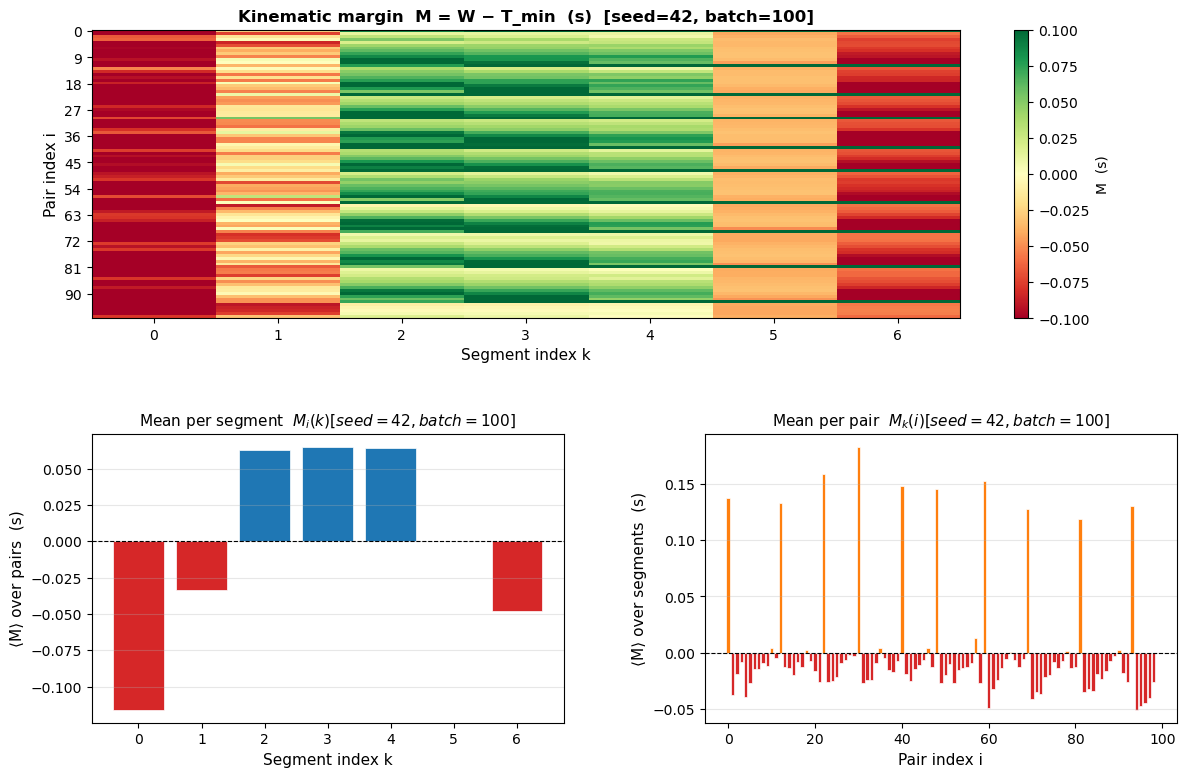

[ 1 13 23 31 41 49 60 70 82 94]


In [8]:
fig = plot_kinematic_margin(result.segment_sync_response, title_suffix=f"seed=42, batch={cfg['batch']}")
print(result.skip_indices + 1)

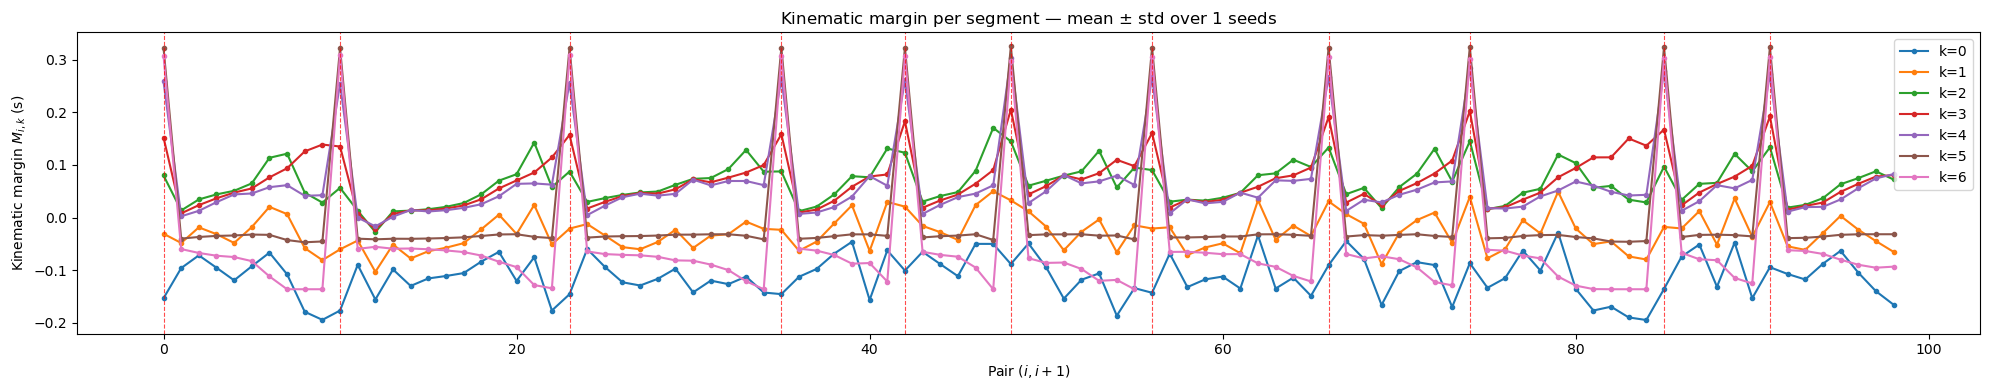

In [9]:
seeds = range(1)
margins = []

for seed in seeds:
    result = sim.run(seed=seed)
    margins.append(result.segment_sync_response.kinematic_margin)

margins = np.stack(margins)  # shape: (n_seeds, n_pairs, n_segments)
n_segments = margins.shape[2]

mean_M = margins.mean(axis=0)
std_M = margins.std(axis=0)

fig, ax = plt.subplots(figsize=(20, 4))

for k in range(0, n_segments):
# for k in range(3):
    ax.plot(mean_M[:, k], label=f'k={k}', marker='.')
    ax.fill_between(
        range(mean_M.shape[0]),
        mean_M[:, k] - std_M[:, k],
        mean_M[:, k] + std_M[:, k],
        alpha=0.2
    )

# skip indices from last run as a representative example
for skip in result.skip_indices:
    ax.axvline(x=skip, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel("Pair $(i, i+1)$")
ax.set_ylabel("Kinematic margin $M_{i,k}$ (s)")
ax.set_title(f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds")
ax.legend()
plt.tight_layout()
plt.show()